In [1]:
# TODO
# - Directly import .bbl files using orangebox library
# - Figure out issue with yaw axis data collection (I think it needs a chirp sweep at a lower frequency?)

In [1]:
from plant_fit import *

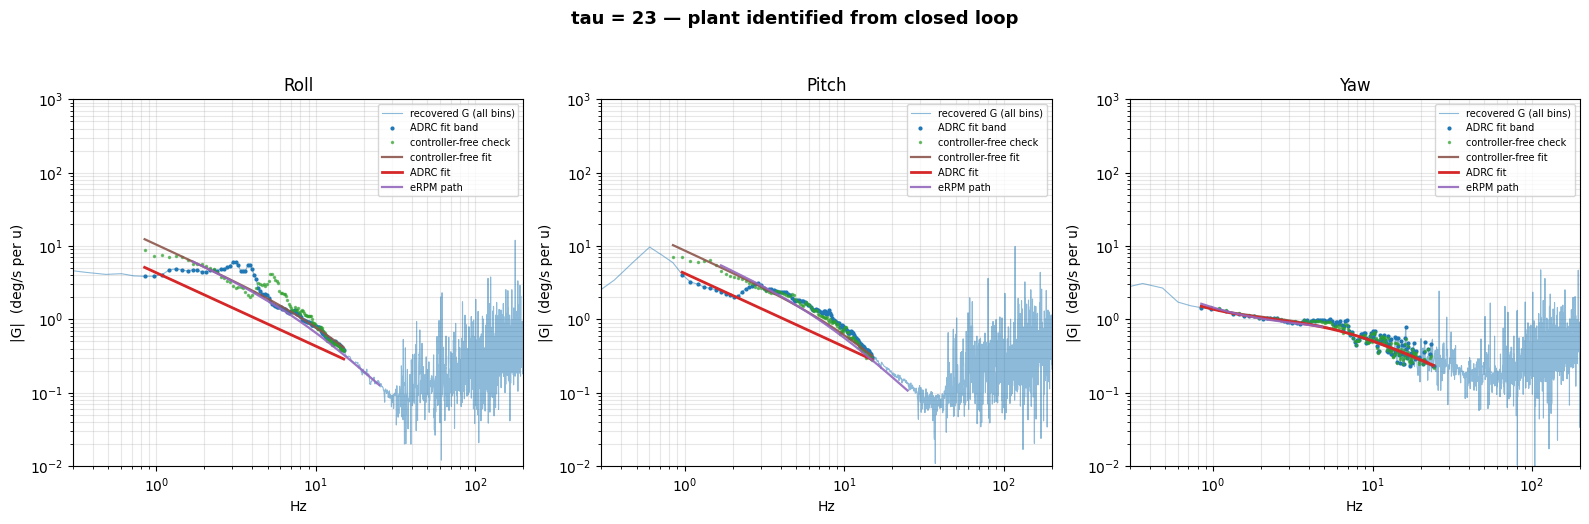

axis,closed-loop / adrc,ctrl-free check,eRPM,gap,configured
roll,2170 +/- 343,3445 +/- 81,2801 +/- 13,25%,2529
pitch,2129 +/- 244,2662 +/- 70,2379 +/- 8,11%,2692
yaw,2690 +/- 51,2628 +/- 36,3139 +/- 108,15%,3021


axis,motor lag (gyro),motor lag (eRPM),delay (gyro),fit err,wo*tau
roll,19.5 +/- 0.8 ms,21.7 +/- 0.3 ms,2.7 ms,0.152,1.75
pitch,22.0 +/- 0.6 ms,19.9 +/- 0.2 ms,2.1 ms,0.111,1.98
yaw,21.8 +/- 1.5 ms,21.3 +/- 1.0 ms,4.4 ms,0.110,1.96



[WARNING:  roll] assumed ADRC controller does not explain the logged output (u/r is 0.94x predicted, -68 deg off) -- the adrc-recovered G is unreliable here; trust ctrl-free/eRPM
[WARNING:  roll] methods disagree on b0 by more than the fit error bars
[WARNING:  roll] 2nd pole above the excited band
[WARNING:  roll] motor lag corner (8 Hz) is not well inside the coherent band (to 19 Hz) -- lag and delay trade off, treat tau as rough
[WARNING: pitch] assumed ADRC controller does not explain the logged output (u/r is 1.09x predicted, -51 deg off) -- the adrc-recovered G is unreliable here; trust ctrl-free/eRPM
[WARNING: pitch] 2nd pole above the excited band
[WARNING:   yaw] yaw is ~1st order at wc (zero at 6.1 rad/s): b0_eff ~ wc x HF gain (37), so re-fit b0 whenever yaw wc changes
[WARNING:   yaw] motor lag corner (7 Hz) is not well inside the coherent band (to 12 Hz) -- lag and delay trade off, treat tau as rough


In [2]:
# Path to betaflight log, should be exported as CSV
#csv_path = '5in chirp.csv'
csv_path = 'C:/Users/jmswe/Downloads/mp2 test flights/5 in/tau = 23.bbl.csv'
#csv_path = 'Good_tune_wobble_btfl_031.bbl.csv'

# Proposed wc (rad/s): the wc you plan to fly. Every b0 reported (the b0 table and the
# per-axis printout) is the b0 that matches the plant at this wc. The plant is not exactly
# b0/s^2, so b0 changes with wc (a lot on yaw) -- re-run this cell if you change wc.
# A single number applies to all axes; use a dict for per-axis values, e.g.
#   wc_proposed = {"roll": 80, "pitch": 80, "yaw": 60}
wc_proposed = 80

# Verbose output: also show the detail columns (yaw HF gain, fit band, data source, wc*(tau+d))
verbose = False

# Was this log flown with ADRC?
#   True  - flown with the wc/wo/b0 below. 
#   False - flown with PID (or anything else).
adrc_flight = True
# ADRC parameters the log was flown with. Only used if adrc_flight = True
# (b0 is still reported at wc_proposed, not at this wc).
wc = {"roll": 80,  "pitch": 80,  "yaw": 80}
wo = {"roll": 90, "pitch": 90, "yaw": 90}
b0 = {"roll": 2529, "pitch": 2692, "yaw": 3021}

# Run the bandwidth / wc analysis?
#   True  - compute and show the bandwidth table (achieved -3dB, vs wc, max wc @45/60 deg,
#           PM at wc), the bandwidth lines in the figure footer, and all warnings.
#   False - skip it (faster). Only the b0 fit is reported, with only the b0-fit warnings
#           (controller mismatch, methods disagree on b0, 2nd pole above excited band).
#           bw_table is returned as None.

# Save the figure and text files to out_dir ('Output metrics')?
#   True  - writes '<log> Plant fit.png', '<log> Plant fit.txt' and '<log> Fit summary tables.txt'
#   False - nothing is written; the figure, tables and warnings are only shown in the notebook
save_outputs = False
suggest_wc = False

# Fit plots of transfer functions, inspect these to make sure they look somewhat reasonable
# If these are nonsensical looking all of the output will be nonsensical

# b0 table with values from each of the fit methods, use your own judgement if these disagree significantly

# From bandwidth table achieved -3dB basically tells the fastest response the system actually keeps up with
# vs wc column has a ratio basically says how fast the controller is responding, this should be around 2x. 
# If this ratio is large (over ~5x) that means something is off, likely b0

# Start tuning with recovered b0 values for each axis for fit that most closely matches recovered G
# This will likely be the controller-free fit band if using a chirp flight

# Yaw plant recovery and subsequent fits are somewhat inconsistent, this seems to be an actual issue with the data
# If a warning appears for the yaw axis saying something extrapolated values, start tuning using wc/wo around
# roll and pitch axis values. 

# If save_outputs = True, results are output into a folder named 'Output metrics'

results, b0_table, bw_table = show_fit_summary(csv_path, wc, wo, b0, f_hi = 15, coh_min = 0.3, adrc_flight = adrc_flight,
                                                    suggest_wc = suggest_wc, save_outputs = save_outputs,
                                                    wc_proposed = wc_proposed, verbose = verbose)
#results, b0_table = show_fit_summary(csv_path, wc, b0, f_hi=15, coh_min=0.3)